# Show2D vmin/vmax gap

In [44]:
import numpy as np
from scipy.ndimage import median_filter

from quantem.widget import Show2D

In [45]:
# synthetic ring pattern shared across tests
rng = np.random.default_rng(42)
n_pixels = 256
pixel_size = 0.05
center = (n_pixels - 1) / 2.0
y, x = np.ogrid[:n_pixels, :n_pixels]
r = np.sqrt((y - center) ** 2 + (x - center) ** 2)
k_2d = r * pixel_size

signal = (
    500 * np.exp(-((k_2d - 2.0) ** 2) / (2 * 0.3**2))
    + 200 * np.exp(-((k_2d - 4.0) ** 2) / (2 * 0.5**2))
).astype(np.float32)
background = (200 * np.exp(-k_2d / 3.0)).astype(np.float32)

# A - raw with Poisson noise, 50 hot pixels
A = rng.poisson(np.clip(signal + background, 0, None)).astype(np.float32)
hot_idx = (rng.integers(0, n_pixels, 50), rng.integers(0, n_pixels, 50))
A[hot_idx] = rng.uniform(2000, 5000, 50).astype(np.float32)

# B - processed one, now with hot pixels median-filtered and the background subtracted
local_med = median_filter(A, size=3).astype(np.float32)
B = A.copy()
B[A > local_med + 500] = local_med[A > local_med + 500]
B = np.clip(B - background, 0, None) #clip

## auto-range makes A/B comparison misleading

Show2D normalizes pixels to `[0, 255]` in:
1 - `_normalize_frame` in `show2d.py:456`

2- `show2d/index.tsx:777-788`, only links %s and not absolute vals

A has hot pixels so max ~5000 but B tops out at 566.
So while they have identical real signals, renders at ~8% brightness in A
(400/5000) but ~71% in B (400/566). And so the panels look completely different

In matplotlib, this can be fixed with: `imshow(A, vmin=0, vmax=600)` for both axes

note: `Show3D` already has proper `vmin`/`vmax` constructor params (323-324), but `Show2D` does not

In [46]:
def test_auto_range_mismatch():
    pct_A = 400 / float(A.max()) * 100
    pct_B = 400 / float(B.max()) * 100
    assert abs(pct_A - pct_B) < 5.0, (
        f"400 counts = {pct_A:.0f}% brightness in A vs {pct_B:.0f}% in B; "
        f"auto-range maps [{A.min():.0f}, {A.max():.0f}] vs [{B.min():.0f}, {B.max():.0f}]"
    )

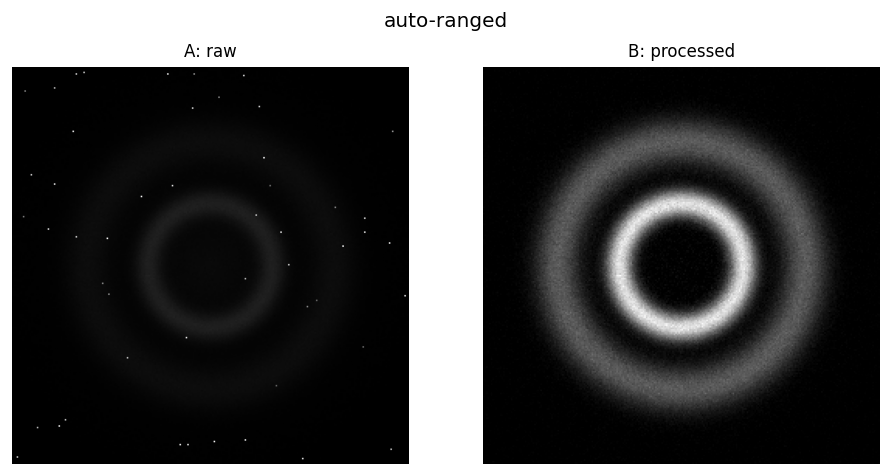

In [47]:
Show2D(
    [A, B],
    labels=["A: raw", "B: processed"],
    title="auto-ranged",
    ncols=2,
    cmap="gray",
)

## possible workaround, pre-clip to shared range

We could force matched scaling by clipping both arrays to same
`[vmin, vmax]` before passing them to `Show2D` but this leads to lossy results,
data outside clipped range is flattened

Link Contrast doesn't work because it syncs %s rather than absolute vals

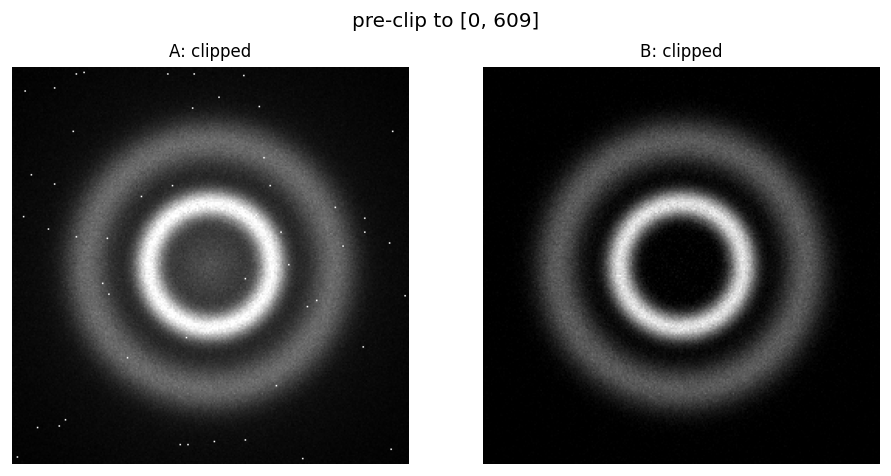

In [48]:
shared_vmax = float(np.percentile(A, 99.5))
Show2D(
    [np.clip(A, 0, shared_vmax), np.clip(B, 0, shared_vmax)], # clip both arrays to same vmin, vmax before passing to Show2D
    labels=["A: clipped", "B: clipped"],
    title=f"pre-clip to [0, {shared_vmax:.0f}]", # demonstrates an accurate but more lossy
    ncols=2,
    cmap="gray",)

In [49]:
def test(fn):
    try:
        fn()
        status = "PASS"
        detail = ""
    except AssertionError as exc:
        status = "FAIL"
        detail = str(exc)
    print(f"{fn.__name__}: {status} {('- ' + detail) if detail else ''}")

test(test_auto_range_mismatch)

test_auto_range_mismatch: FAIL - 400 counts = 8% brightness in A vs 71% in B; auto-range maps [2, 4969] vs [0, 566]
